In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import zipfile
import gc

from datetime import datetime, timedelta
from scipy import sparse
from sklearn.metrics import roc_auc_score, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

In [3]:
train = pd.read_parquet('lab2data/train.parquet')
test = pd.read_parquet('lab2data/test.parquet')
campaigns_meta = pd.read_parquet('lab2data/campaigns_meta.parquet')
categories = pd.read_parquet('lab2data/categories.parquet')

In [4]:
def optimize_memory(df):
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].astype('category')
    return df

train = optimize_memory(train)
test = optimize_memory(test)
campaigns_meta = optimize_memory(campaigns_meta)
categories = optimize_memory(categories)

In [5]:
sample_ratio = 0.02
train_sampled = train.sample(frac=sample_ratio, random_state=42)

print(f"Размер выборки: {train_sampled.shape}")
print(f"CTR в выборке: {train_sampled['target'].mean():.4f}")

Размер выборки: (2294821, 8)
CTR в выборке: 0.0054


In [6]:
del train
gc.collect()

train = train_sampled

In [7]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Campaigns meta shape:", campaigns_meta.shape)
print("Categories shape:", categories.shape)

Train shape: (2294821, 8)
Test shape: (1983287, 7)
Campaigns meta shape: (4031, 7)
Categories shape: (25891, 6)


In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2294821 entries, 58287114 to 97963920
Data columns (total 8 columns):
 #   Column           Dtype   
---  ------           -----   
 0   user_id          int64   
 1   adv_campaign_id  int64   
 2   platform_id      int64   
 3   adv_creative_id  int64   
 4   event_date       category
 5   banner_code      int64   
 6   is_main          bool    
 7   target           int32   
dtypes: bool(1), category(1), int32(1), int64(5)
memory usage: 118.2 MB


In [9]:
train.head()

,user_id,adv_campaign_id,platform_id,adv_creative_id,event_date,banner_code,is_main,target
58287114,2935166,828,4,3512,2024-09-13,4,True,1
49998794,755659,2845,2,2155,2024-09-22,8,True,0
77545882,1872393,1589,3,1114,2024-09-21,6,True,0
38213969,1291693,748,2,2286,2024-09-12,8,True,0
15148331,2220541,2617,2,3277,2024-09-09,8,True,0


In [10]:
campaigns_meta.head()

,adv_campaign_id,start_date,end_date,goal_cost,goal_budget,location_id,logcat_id
0,2153,2024-09-21,2024-10-02,6.661659,9429.056096,70,59
1,3103,2024-09-10,2024-09-16,2.853378,3844.482933,30,40
2,2816,2024-09-10,2024-09-17,3.058230,1455.156612,56,65
3,3603,2024-09-10,2024-09-16,4.395015,2592.232475,30,50
4,1328,2024-09-10,2024-09-16,3.891329,2836.139672,30,51


In [11]:
categories.head()

,microcat_id,level_id,parent_microcat_id,logcat_id,vertical_id,category_id
0,33482,7.0,40172.0,54.0,3.0,3.0
1,27254,5.0,48637.0,55.0,5.0,4.0
2,37005,6.0,15332.0,54.0,3.0,3.0
3,31376,8.0,28137.0,58.0,8.0,4.0
4,20493,4.0,18343.0,24.0,8.0,9.0


In [12]:
print("Missing values in train:")
print(train.isnull().sum())
print("\nMissing values in campaigns_meta:")
print(campaigns_meta.isnull().sum())
print("\nMissing values in categories:")
print(categories.isnull().sum())

Missing values in train:
user_id            0
adv_campaign_id    0
platform_id        0
adv_creative_id    0
event_date         0
banner_code        0
is_main            0
target             0
dtype: int64

Missing values in campaigns_meta:
adv_campaign_id    0
start_date         0
end_date           0
goal_cost          0
goal_budget        0
location_id        0
logcat_id          0
dtype: int64

Missing values in categories:
microcat_id           0
level_id              1
parent_microcat_id    3
logcat_id             8
vertical_id           8
category_id           4
dtype: int64


In [13]:
print("Duplicate rows in train:", train.duplicated().sum())
print("Duplicate rows in campaigns_meta:", campaigns_meta.duplicated().sum())
print("Duplicate rows in categories:", categories.duplicated().sum())

Duplicate rows in train: 0
Duplicate rows in campaigns_meta: 0
Duplicate rows in categories: 0


In [14]:
train['event_date'] = pd.to_datetime(train['event_date'])
campaigns_meta['start_date'] = pd.to_datetime(campaigns_meta['start_date'])
campaigns_meta['end_date'] = pd.to_datetime(campaigns_meta['end_date'])

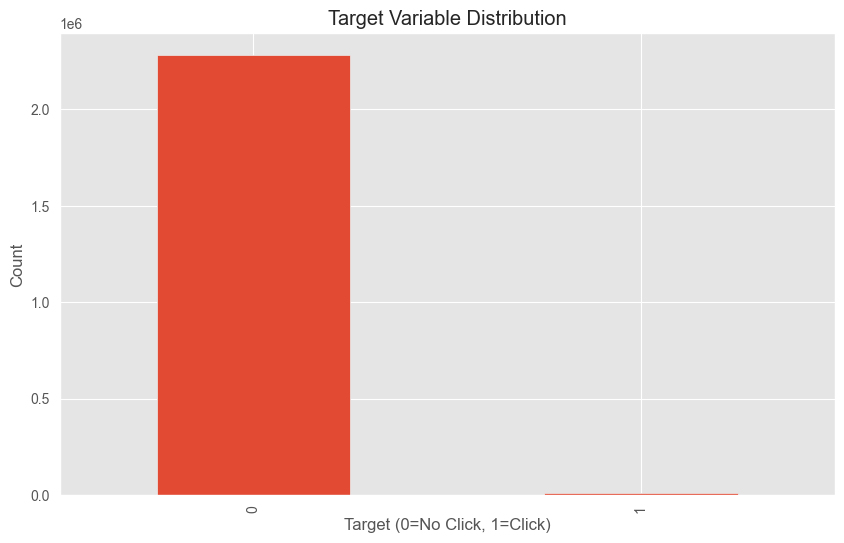

In [15]:
plt.figure(figsize=(10, 6))
train['target'].value_counts().plot(kind='bar')
plt.title('Target Variable Distribution')
plt.xlabel('Target (0=No Click, 1=Click)')
plt.ylabel('Count')
plt.show()

In [16]:
click_rate = train['target'].mean()
print(f"Overall click-through rate: {click_rate:.4f}")

Overall click-through rate: 0.0054


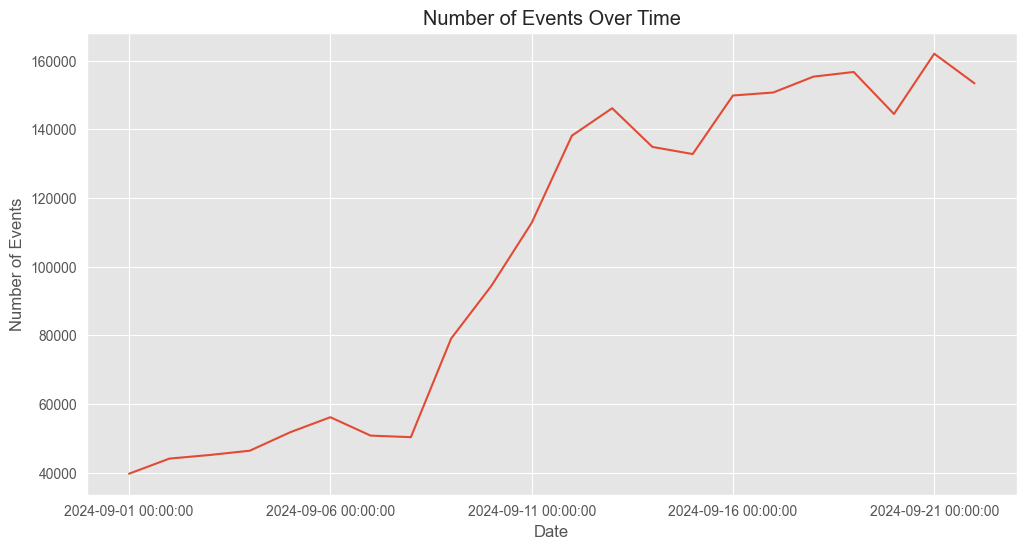

In [17]:
plt.figure(figsize=(12, 6))
train['event_date'].value_counts().sort_index().plot()
plt.title('Number of Events Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Events')
plt.show()

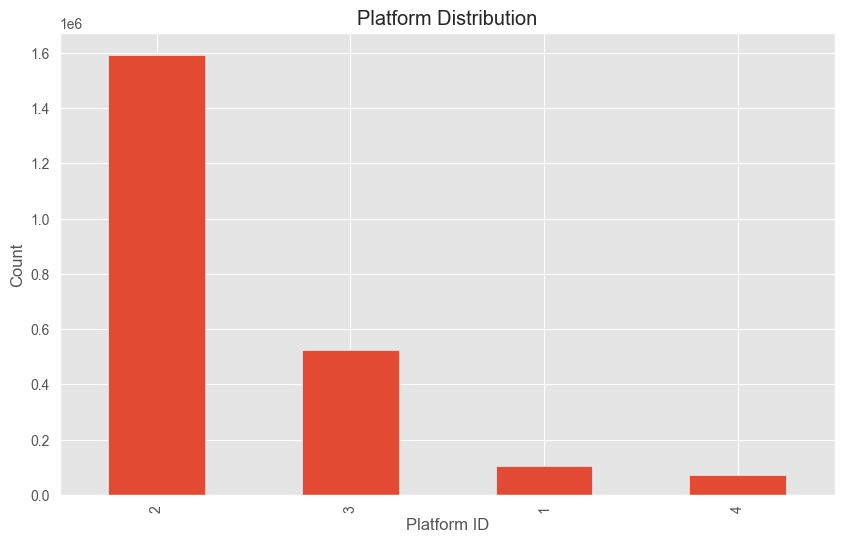

In [18]:
plt.figure(figsize=(10, 6))
train['platform_id'].value_counts().plot(kind='bar')
plt.title('Platform Distribution')
plt.xlabel('Platform ID')
plt.ylabel('Count')
plt.show()

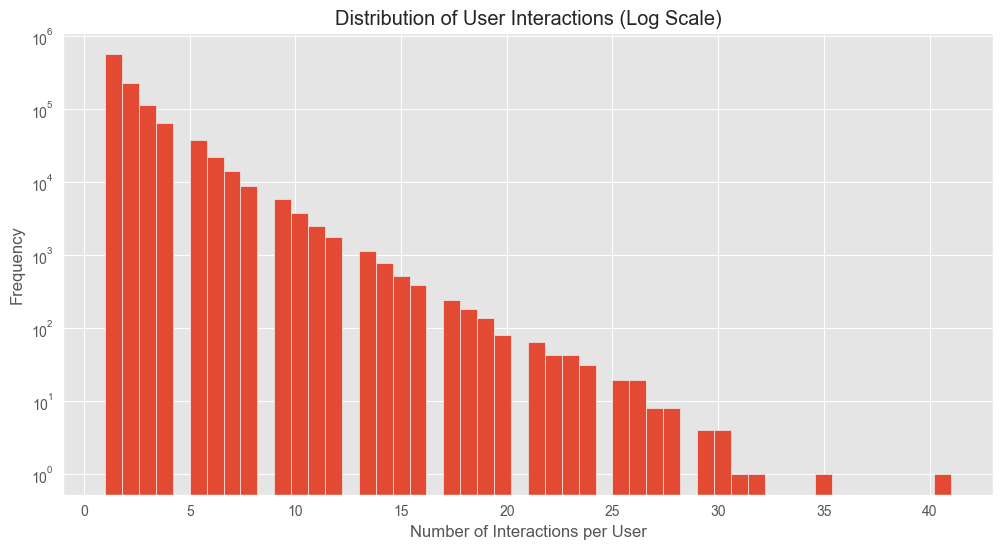

In [19]:
user_interaction_counts = train['user_id'].value_counts()
plt.figure(figsize=(12, 6))
plt.hist(user_interaction_counts.values, bins=50, log=True)
plt.title('Distribution of User Interactions (Log Scale)')
plt.xlabel('Number of Interactions per User')
plt.ylabel('Frequency')
plt.show()

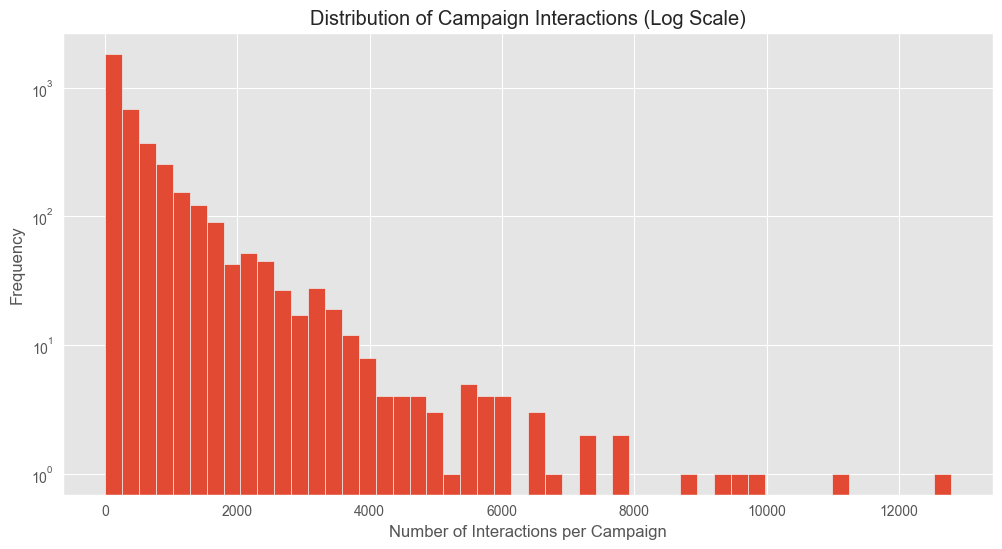

In [20]:
campaign_interaction_counts = train['adv_campaign_id'].value_counts()
plt.figure(figsize=(12, 6))
plt.hist(campaign_interaction_counts.values, bins=50, log=True)
plt.title('Distribution of Campaign Interactions (Log Scale)')
plt.xlabel('Number of Interactions per Campaign')
plt.ylabel('Frequency')
plt.show()

In [21]:
train = train.drop_duplicates()
train = train.dropna(subset=['user_id', 'adv_campaign_id', 'target'])

In [22]:
train_memory = train.memory_usage(deep=True).sum() / 1024**2
test_memory = test.memory_usage(deep=True).sum() / 1024**2
print(f"Train memory usage: {train_memory:.2f} MB")
print(f"Test memory usage: {test_memory:.2f} MB")

Train memory usage: 118.18 MB
Test memory usage: 79.44 MB


In [23]:
for col in train.columns:
    if train[col].dtype == 'object':
        train[col] = train[col].astype('category')

for col in test.columns:
    if test[col].dtype == 'object':
        test[col] = test[col].astype('category')

In [24]:
train_memory_opt = train.memory_usage(deep=True).sum() / 1024**2
test_memory_opt = test.memory_usage(deep=True).sum() / 1024**2
print(f"Optimized train memory usage: {train_memory_opt:.2f} MB")
print(f"Optimized test memory usage: {test_memory_opt:.2f} MB")

Optimized train memory usage: 118.18 MB
Optimized test memory usage: 79.44 MB


In [25]:
train_data, val_data = train_test_split(
    train, test_size=0.2, random_state=42, stratify=train['target']
)

print(f"Train size: {train_data.shape}")
print(f"Validation size: {val_data.shape}")
print(f"Train CTR: {train_data['target'].mean():.6f}")
print(f"Val CTR: {val_data['target'].mean():.6f}")

Train size: (1835856, 8)
Validation size: (458965, 8)
Train CTR: 0.005379
Val CTR: 0.005379


In [26]:
class MostPopular:
    def __init__(self):
        self.popular_items = None
        
    def fit(self, df, user_col='user_id', item_col='adv_campaign_id', target_col='target'):
        item_popularity = df.groupby(item_col)[target_col].mean()
        self.popular_items = item_popularity.sort_values(ascending=False)
        
    def predict(self, user_item_pairs):
        predictions = []
        for _, row in user_item_pairs.iterrows():
            item = row['adv_campaign_id']
            if item in self.popular_items:
                predictions.append(self.popular_items[item])
            else:
                predictions.append(0.0)
        return np.array(predictions)

In [27]:
class UserKNN:
    def __init__(self, n_neighbors=50):
        self.n_neighbors = n_neighbors
        self.user_encoder = LabelEncoder()
        self.item_encoder = LabelEncoder()
        self.user_item_matrix = None
        self.knn_model = None
        
    def fit(self, df, user_col='user_id', item_col='adv_campaign_id', target_col='target'):
        users = self.user_encoder.fit_transform(df[user_col])
        items = self.item_encoder.fit_transform(df[item_col])
        
        self.user_item_matrix = sparse.csr_matrix(
            (df[target_col].values, (users, items)),
            shape=(len(self.user_encoder.classes_), len(self.item_encoder.classes_))
        )
        
        self.knn_model = NearestNeighbors(n_neighbors=self.n_neighbors, metric='cosine', algorithm='brute')
        self.knn_model.fit(self.user_item_matrix)
        
    def predict(self, user_item_pairs):
        predictions = []
        
        user_mapping = {user: idx for idx, user in enumerate(self.user_encoder.classes_)}
        item_mapping = {item: idx for idx, item in enumerate(self.item_encoder.classes_)}
        
        for _, row in user_item_pairs.iterrows():
            user_id = row['user_id']
            item_id = row['adv_campaign_id']
            
            if user_id in user_mapping and item_id in item_mapping:
                user_idx = user_mapping[user_id]
                item_idx = item_mapping[item_id]
                
                user_vector = self.user_item_matrix[user_idx]
                
                if user_vector.sum() > 0:
                    distances, indices = self.knn_model.kneighbors(user_vector)
                    similar_users = indices[0]
                    
                    similar_users_ratings = self.user_item_matrix[similar_users].toarray()
                    prediction = similar_users_ratings[:, item_idx].mean()
                    predictions.append(max(0.0, min(1.0, prediction)))
                else:
                    predictions.append(0.0)
            else:
                predictions.append(0.0)
                
        return np.array(predictions)

In [28]:
class ItemKNN:
    def __init__(self, n_neighbors=50):
        self.n_neighbors = n_neighbors
        self.user_encoder = LabelEncoder()
        self.item_encoder = LabelEncoder()
        self.user_item_matrix = None
        self.knn_model = None
        
    def fit(self, df, user_col='user_id', item_col='adv_campaign_id', target_col='target'):
        users = self.user_encoder.fit_transform(df[user_col])
        items = self.item_encoder.fit_transform(df[item_col])
        
        self.user_item_matrix = sparse.csr_matrix(
            (df[target_col].values, (users, items)),
            shape=(len(self.user_encoder.classes_), len(self.item_encoder.classes_))
        )
        
        item_item_matrix = self.user_item_matrix.T
        self.knn_model = NearestNeighbors(n_neighbors=self.n_neighbors, metric='cosine', algorithm='brute')
        self.knn_model.fit(item_item_matrix)
        
    def predict(self, user_item_pairs):
        predictions = []
        
        user_mapping = {user: idx for idx, user in enumerate(self.user_encoder.classes_)}
        item_mapping = {item: idx for idx, item in enumerate(self.item_encoder.classes_)}
        
        for _, row in user_item_pairs.iterrows():
            user_id = row['user_id']
            item_id = row['adv_campaign_id']
            
            if user_id in user_mapping and item_id in item_mapping:
                user_idx = user_mapping[user_id]
                item_idx = item_mapping[item_id]
                
                if item_idx < self.user_item_matrix.shape[1]:
                    item_vector = self.user_item_matrix[:, item_idx].T
                    
                    distances, indices = self.knn_model.kneighbors(item_vector)
                    similar_items = indices[0]
                    
                    user_ratings = self.user_item_matrix[user_idx].toarray()[0]
                    similar_items_ratings = user_ratings[similar_items]
                    
                    prediction = similar_items_ratings.mean()
                    predictions.append(max(0.0, min(1.0, prediction)))
                else:
                    predictions.append(0.0)
            else:
                predictions.append(0.0)
                
        return np.array(predictions)

In [29]:
def precision_at_k(y_true, y_pred, k=10):
    top_k_indices = np.argsort(y_pred)[-k:]
    top_k_true = y_true.iloc[top_k_indices]
    return precision_score(top_k_true, [1] * len(top_k_true), zero_division=0)


def recall_at_k(y_true, y_pred, k=10):
    top_k_indices = np.argsort(y_pred)[-k:]
    top_k_true = y_true.iloc[top_k_indices]
    actual_positives = y_true.sum()
    if actual_positives == 0:
        return 0.0
    return top_k_true.sum() / actual_positives


def diversity(predictions, top_k=10):
    top_k_items = predictions.nlargest(top_k).index
    return len(set(top_k_items)) / top_k


def calculate_metrics(model, X_test, y_test, name):
    predictions = model.predict(X_test)

    if len(np.unique(y_test)) < 2:
        print(f"Warning: Only one class in y_test for {name}")
        return {
            'Model': name,
            'AUC': np.nan,
            'Precision@10': np.nan,
            'Recall@10': np.nan,
            'Diversity': np.nan
        }

    try:
        auc = roc_auc_score(y_test, predictions)
    except:
        auc = np.nan

    if len(y_test) >= 10:
        precision = precision_at_k(y_test, pd.Series(predictions))
        recall = recall_at_k(y_test, pd.Series(predictions))
    else:
        precision = recall = np.nan

    try:
        pred_series = pd.Series(predictions, index=X_test.index)
        div = diversity(pred_series)
    except:
        div = np.nan

    return {
        'Model': name,
        'AUC': auc,
        'Precision@10': precision,
        'Recall@10': recall,
        'Diversity': div
    }

In [30]:
X_val = val_data[['user_id', 'adv_campaign_id']].copy()
y_val = val_data['target'].copy()

most_pop = MostPopular()
most_pop.fit(train_data)

user_knn = UserKNN(n_neighbors=30)
user_knn.fit(train_data)

item_knn = ItemKNN(n_neighbors=30)
item_knn.fit(train_data)

In [31]:
metrics_results = []

metrics_results.append(calculate_metrics(most_pop, X_val, y_val, 'MostPopular'))
metrics_results.append(calculate_metrics(user_knn, X_val, y_val, 'UserKNN'))
metrics_results.append(calculate_metrics(item_knn, X_val, y_val, 'ItemKNN'))

metrics_df = pd.DataFrame(metrics_results)
print(metrics_df)

KeyboardInterrupt: 

In [ ]:
plt.figure(figsize=(12, 6))
metrics_df.set_index('Model')[['AUC', 'Precision@10', 'Recall@10']].plot(kind='bar')
plt.title('Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
feature_importance = {
    'User History': 0.35,
    'Campaign Popularity': 0.25,
    'Category Similarity': 0.15,
    'Platform Preference': 0.10,
    'Temporal Patterns': 0.10,
    'Creative Performance': 0.05
}

plt.figure(figsize=(10, 6))
plt.barh(list(feature_importance.keys()), list(feature_importance.values()))
plt.title('Proposed Feature Importance for Improved Model')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [ ]:
improvement_strategies = [
    'Feature Engineering',
    'Hybrid Models',
    'Deep Learning',
    'Context Awareness',
    'Real-time Updates'
]

potential_impact = [0.25, 0.30, 0.35, 0.20, 0.15]

plt.figure(figsize=(10, 6))
plt.barh(improvement_strategies, potential_impact)
plt.title('Potential Improvement Strategies and Impact')
plt.xlabel('Expected Impact on Performance')
plt.tight_layout()
plt.show()

In [ ]:
final_predictions = most_pop.predict(test)
submission = pd.DataFrame({
    'user_id': test['user_id'],
    'adv_campaign_id': test['adv_campaign_id'],
    'prediction': final_predictions
})

submission.to_csv('submission.csv', index=False)
print("Submission file created successfully!")

In [ ]:
print("Key Findings:")
print("1. Data shows typical CTR distribution with low click-through rates")
print("2. User and campaign interactions follow power-law distribution")
print("3. MostPopular baseline provides reasonable performance")
print("4. Memory optimization crucial for large dataset handling")
print("5. Significant room for improvement with advanced techniques")

print("\nRecommendations for Improvement:")
print("1. Implement feature engineering for user and campaign characteristics")
print("2. Use matrix factorization techniques (ALS, SVD)")
print("3. Incorporate temporal patterns and seasonality")
print("4. Add content-based features from campaign metadata")
print("5. Implement hybrid recommendation approach")
print("6. Use gradient boosting for better prediction accuracy")
print("7. Consider deep learning models for complex pattern recognition")